# Project Deliverable 3: Linear Classification Model

## Section 0: Setup and Databset Init
Import SparkSession from pyspark.sql, and initialize a SparkSession. Also import all the necessary functions from pyspark.sql.functions and all necessary classes from pyspark.sql.types

In [1]:
import os
import sys

from pyspark.sql.functions import broadcast, explode, split, col, avg, count ,round, desc
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = SparkSession.builder \
    .appName("Week 6 Project 1 Works") \
    .master("local[*]") \
    .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/22 23:51:27 WARN Utils: Your hostname, Mostafizurs-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.0.0.171 instead (on interface en0)
26/03/22 23:51:27 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/22 23:51:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### Users
This is the given schema for the users dataset in the README:

UserID::Gender::Age::Occupation::Zip-code


In [2]:
schema_users = StructType([
    StructField("UserID", IntegerType(), True),
    StructField("Gender", StringType(), True),
    StructField("Age", IntegerType(), True),
    StructField("Occupation",IntegerType(), True),
    StructField("Zip-code", StringType(), True)
])

df_users = spark.read \
    .option("header", "false") \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("multiLine", "true") \
    .option("sep", "::") \
    .schema(schema_users) \
    .csv("./ml-1m/users.dat")

Print the schema of the users table:

In [3]:
df_users.printSchema()

root
 |-- UserID: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Occupation: integer (nullable = true)
 |-- Zip-code: string (nullable = true)



### Ratings 
This is the given schema for the ratings dataset in the README:

UserID::MovieID::Rating::Timestamp

In [4]:
schema_ratings  = StructType([
    StructField("UserID", IntegerType(), True),
    StructField("MovieID", IntegerType(), True),
    StructField("Rating", IntegerType(), True),
    StructField("Timestamp",IntegerType(), True)
])

df_ratings = spark.read \
    .option("header", "false") \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("multiLine", "true") \
    .option("sep", "::") \
    .schema(schema_ratings) \
    .csv("./ml-1m/ratings.dat")

df_ratings.show(5)

+------+-------+------+---------+
|UserID|MovieID|Rating|Timestamp|
+------+-------+------+---------+
|     1|   1193|     5|978300760|
|     1|    661|     3|978302109|
|     1|    914|     3|978301968|
|     1|   3408|     4|978300275|
|     1|   2355|     5|978824291|
+------+-------+------+---------+
only showing top 5 rows


### Movies 
This is the given schema for the movies dataset in the README:

MovieID::Title::Genres

In [5]:
schema_movies  = StructType([
    StructField("MovieID", IntegerType(), True),
    StructField("Title", StringType(), True),
    StructField("Genres",StringType(), True)
])

df_movies = spark.read \
    .option("header", "false") \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("multiLine", "true") \
    .option("sep", "::") \
    .schema(schema_movies) \
    .csv("./ml-1m/movies.dat")



In [6]:
df_movies.show(5)

+-------+--------------------+--------------------+
|MovieID|               Title|              Genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Animation|Childre...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|        Comedy|Drama|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows


## Section 2: Join the Tables
Ratings is joined with Movies on MovieID, and joined with Users on UserID, and the result is stored in df_joined.

In [7]:
df_joined = df_ratings \
    .join(broadcast(df_users), on="UserID", how="inner") \
    .join(broadcast(df_movies), on="MovieID", how="inner")

Print the schema of the joined tables:

In [8]:
df_joined.printSchema()

root
 |-- MovieID: integer (nullable = true)
 |-- UserID: integer (nullable = true)
 |-- Rating: integer (nullable = true)
 |-- Timestamp: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Occupation: integer (nullable = true)
 |-- Zip-code: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Genres: string (nullable = true)



# Deliverable 2: Data Cleaning & Feature Exploration

## Section 1: Data Cleaning
Run quick checks for duplicates, referential integrity, out-of-range values, invalid age/occupation codes, and null counts.

### 1a. Quality Checks

#### 1. **Duplicate ratings**: Are there any rows where the same user_id rated the same movie_id more than once?

In [9]:
from pyspark.sql.functions import col

duplicates = df_ratings.groupBy("UserID", "MovieID").count().filter(col("count") > 1)

duplicates.show(10)
print("Number of duplicate (UserID, MovieID) pairs:", duplicates.count())

+------+-------+-----+
|UserID|MovieID|count|
+------+-------+-----+
+------+-------+-----+



[Stage 9:>                                                          (0 + 1) / 1]

Number of duplicate (UserID, MovieID) pairs: 0


**Answer**: No duplicate ratings found. All 1,000,209 rows have unique (UserID, MovieID) combinations.

#### 2. **Referential integrity**: Do all user_id values in the ratings table exist in the users table? Do all movie_id values exist in the movies table? (Use anti-joins to check.)


2.1 Referential integrity: Users

In [10]:
missing_users = df_ratings.join(df_users.select("UserID"), on="UserID", how="left_anti")

missing_users.show()
missing_users.count()

+------+-------+------+---------+
|UserID|MovieID|Rating|Timestamp|
+------+-------+------+---------+
+------+-------+------+---------+



0

Answer: 0 ratings contain UserID values that do not exist in the users table.

2.2 Referential integrity: Movies

In [11]:
missing_movies = df_ratings.join(df_movies.select("MovieID"), on="MovieID", how="left_anti")

missing_movies.show()
missing_movies.count()

+-------+------+------+---------+
|MovieID|UserID|Rating|Timestamp|
+-------+------+------+---------+
+-------+------+------+---------+



0

Answer: 0 ratings contain MovieID values that do not exist in the movies table.

#### 3. Out-of-range values: 
#### 3.1 Are all ratings between 1 and 5?

In [12]:
from pyspark.sql.functions import col

out_of_range = df_ratings.filter((col("Rating") < 1) | (col("Rating") > 5))

out_of_range.show()
out_of_range.count()

+------+-------+------+---------+
|UserID|MovieID|Rating|Timestamp|
+------+-------+------+---------+
+------+-------+------+---------+



0

Answer: 0 ratings are outside the valid 1–5 range.

#### 3.2 Are all age values valid MovieLens age codes (1, 18, 25, 35, 45, 50, 56)?

In [13]:
df_users.select("Age").distinct().orderBy("Age").show()

+---+
|Age|
+---+
|  1|
| 18|
| 25|
| 35|
| 45|
| 50|
| 56|
+---+



Answer: The Age codes present are 1, 18, 25, 35, 45, 50, and 56. All values match the valid MovieLens age categories.

#### 3.3 Are all occupation codes between 0 and 20?

In [14]:
df_users.select("Occupation").distinct().orderBy("Occupation").show()

+----------+
|Occupation|
+----------+
|         0|
|         1|
|         2|
|         3|
|         4|
|         5|
|         6|
|         7|
|         8|
|         9|
|        10|
|        11|
|        12|
|        13|
|        14|
|        15|
|        16|
|        17|
|        18|
|        19|
+----------+
only showing top 20 rows


Answer: The occupation codes present range from 0 to 20. All values fall within the expected MovieLens occupation categories.

#### 4. Null audit: For each column in your joined DataFrame, report the number of nulls. Show the results in a summary table

In [15]:
from pyspark.sql.functions import col

null_counts_list = []
for c in df_joined.columns:
    null_counts_list.append((c, df_joined.filter(col(c).isNull()).count()))

spark.createDataFrame(null_counts_list, ["column", "null_count"]).show()

+----------+----------+
|    column|null_count|
+----------+----------+
|   MovieID|         0|
|    UserID|         0|
|    Rating|         0|
| Timestamp|         0|
|    Gender|         0|
|       Age|         0|
|Occupation|         0|
|  Zip-code|         0|
|     Title|         0|
|    Genres|         0|
+----------+----------+



### 1b. Cleaning Actions

#### 1b.1.1 Duplicate ratings (BEFORE)
Check if any (UserID, MovieID) pair appears more than once.

In [16]:
from pyspark.sql.functions import col

dup_before = df_ratings.groupBy("UserID", "MovieID").count().filter(col("count") > 1)

dup_before.show()
dup_before.count()

+------+-------+-----+
|UserID|MovieID|count|
+------+-------+-----+
+------+-------+-----+



0

#### 1b.1.2 Duplicate ratings (FIX)
If duplicates exist, drop duplicates so each (UserID, MovieID) appears once.

In [17]:
# Only run this if dup_before.count() was > 0
df_ratings = df_ratings.dropDuplicates(["UserID", "MovieID"])
df_ratings.count()

1000209

#### 1b.1.3 Duplicate ratings (AFTER)
Verify that duplicate (UserID, MovieID) pairs are now 0.

In [18]:
from pyspark.sql.functions import col

dup_after = df_ratings.groupBy("UserID", "MovieID").count().filter(col("count") > 1)

dup_after.show()
dup_after.count()

+------+-------+-----+
|UserID|MovieID|count|
+------+-------+-----+
+------+-------+-----+



0

In [19]:
df_ratings.count()

1000209

Answer: No fix was needed because the BEFORE count was 0.

#### 1b.2.1 Referential integrity(Users)(BEFORE)
Check if any ratings contain a UserID that does not exist in the users table.

In [20]:
missing_users = df_ratings.join(df_users.select("UserID"), on="UserID", how="left_anti")
missing_users.count()

0

#### 1b.2.2 Referential integrity (Users)(FIX)
Only use this if the BEFORE count was > 0; drop ratings with UserID values not found in the users table.

In [21]:
df_ratings = df_ratings.join(df_users.select("UserID"), on="UserID", how="inner")

#### 1b.2.3 Referential integrity (Users)(AFTER)
Verify that UserID count is now 0.

In [22]:
df_ratings.join(df_users.select("UserID"), on="UserID", how="left_anti").count()

0

Answer: No fix was needed because the BEFORE count was 0.

#### 1b.3.1 Referential integrity(Movies)(BEFORE)
Check if any ratings contain a MovieID that does not exist in the movies table.

In [23]:
missing_movies = df_ratings.join(df_movies.select("MovieID"), on="MovieID", how="left_anti")
missing_movies.count()

0

#### 1b.3.2 Referential integrity (Movies)(FIX)
Only use this if the BEFORE count was > 0; drop ratings with MovieID values not found in the movies table.

In [24]:
df_ratings = df_ratings.join(df_movies.select("MovieID"), on="MovieID", how="inner")

#### 1b.3.3 Referential integrity (Movies)(AFTER)
Verify that the orphan MovieID count is now 0.

In [25]:
df_ratings.join(df_movies.select("MovieID"), on="MovieID", how="left_anti").count()

0

No fix was needed because the BEFORE count was 0.

#### 1b.4.1 Rating range (BEFORE)
Check if any ratings fall outside the valid 1–5 range.

In [26]:
from pyspark.sql.functions import col

out_of_range = df_ratings.filter((col("Rating") < 1) | (col("Rating") > 5))
out_of_range.count()

0

#### 1b.4.2 Rating range (FIX)
Only use this if the BEFORE count was > 0; remove ratings outside the 1–5 range.

In [27]:
df_ratings = df_ratings.filter((col("Rating") >= 1) & (col("Rating") <= 5))

#### 1b.4.3 Rating range (AFTER)
Verify that the out-of-range rating count is now 0.

In [28]:
df_ratings.filter((col("Rating") < 1) | (col("Rating") > 5)).count()

0

Answer: No fix was needed because the BEFORE count was 0.

#### 1b.5.1 Null audit (BEFORE)
Count the number of null values in each column of df_joined.

In [29]:
from pyspark.sql.functions import col

null_counts_before = []
for c in df_joined.columns:
    null_counts_before.append((c, df_joined.filter(col(c).isNull()).count()))

spark.createDataFrame(null_counts_before, ["column", "null_count"]).show()

+----------+----------+
|    column|null_count|
+----------+----------+
|   MovieID|         0|
|    UserID|         0|
|    Rating|         0|
| Timestamp|         0|
|    Gender|         0|
|       Age|         0|
|Occupation|         0|
|  Zip-code|         0|
|     Title|         0|
|    Genres|         0|
+----------+----------+



#### 1b.5.2 Null audit (FIX)
Only use this if any null_count values were > 0; fill missing Genres with "Unknown".

In [30]:
df_joined = df_joined.fillna({"Genres": "Unknown", "Title": "Unknown"})

#### 1b.5.3 Null audit (AFTER)
Verify the number of null values in each column of df_joined after the fix.

In [31]:
null_counts_after = []
for c in df_joined.columns:
    null_counts_after.append((c, df_joined.filter(col(c).isNull()).count()))

spark.createDataFrame(null_counts_after, ["column", "null_count"]).show()

+----------+----------+
|    column|null_count|
+----------+----------+
|   MovieID|         0|
|    UserID|         0|
|    Rating|         0|
| Timestamp|         0|
|    Gender|         0|
|       Age|         0|
|Occupation|         0|
|  Zip-code|         0|
|     Title|         0|
|    Genres|         0|
+----------+----------+



## Section 2: Feature Engineering

### 2a. Define Target and Predictors

### Feature Documentation Table

| Group | # | Feature Name | Type | Source | How Computed | Why Potentially Predictive |
|---|---:|---|---|---|---|---|
| Target | 0 | high_rating | Binary (0/1) | Derived from Rating | `when(col("Rating") >= 4, 1).otherwise(0)` | This is the target variable indicating whether a rating is high |
| Predictor | 1 | user_avg_rating | Continuous | Derived from ratings | `groupBy("UserID").avg("Rating")` | Captures each user's typical rating behavior |
| Predictor | 2 | movie_avg_rating | Continuous | Derived from ratings | `groupBy("MovieID").avg("Rating")` | Captures the overall rating tendency of a movie |
| Predictor | 3 | movie_popularity | Integer | Derived from ratings | `groupBy("MovieID").count()` | Frequently rated movies may have more stable rating patterns |
| Predictor | 4 | user_rating_count | Integer | Derived from ratings | `groupBy("UserID").count()` | More active users may show more stable or distinctive rating behavior |
| Predictor | 5 | gender_encoded | Binary (0/1) | Derived from users.dat / Gender | `F -> 1, M -> 0` | User demographics may affect rating preferences |
| Predictor | 6 | num_genres | Integer | Derived from movies.dat / Genres | `size(split(col("Genres"), "\\"))` | Multi-genre movies may appeal differently than single-genre movies |
| Predictor | 7 | release_year | Integer | Derived from movies.dat / Title | `regexp_extract(col("Title"), r"\\((\\d{4})\\)", 1).cast("int")` | Movie era may influence audience preferences and ratings |
| Predictor | 8 | movie_age | Integer | Derived from release_year | `2000 - release_year` | Older vs newer movies may receive different rating patterns |

### Optional reset block for reruns:
If these engineered columns already exist from an earlier notebook run, drop them first so the feature-creation cells can be re-executed cleanly.


In [32]:
from pyspark.sql.functions import col, when, split, size, regexp_extract, length
cols_to_drop = [
    "high_rating", "user_avg_rating", "movie_avg_rating", "movie_popularity", "user_rating_count",
    "gender_encoded", "num_genres", "release_year", "movie_age"
]

for column in cols_to_drop:
    if column in df_joined.columns:
        df_joined = df_joined.drop(column)

df_joined.printSchema()

root
 |-- MovieID: integer (nullable = true)
 |-- UserID: integer (nullable = true)
 |-- Rating: integer (nullable = true)
 |-- Timestamp: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Occupation: integer (nullable = true)
 |-- Zip-code: string (nullable = true)
 |-- Title: string (nullable = false)
 |-- Genres: string (nullable = false)



#### 0) Target: high_rating

In [33]:
df_joined = df_joined.withColumn("high_rating", when(col("Rating") >= 4, 1).otherwise(0))

#### 1) user_avg_rating

In [34]:
df_joined = df_joined.join(df_joined.groupBy("UserID").agg({"Rating":"avg"}).withColumnRenamed("avg(Rating)", "user_avg_rating"), on="UserID", how="left")

#### 2) movie_avg_rating

In [35]:
movie_avg = df_joined.groupBy("MovieID").agg(avg("Rating").alias("movie_avg_rating"))
df_joined = df_joined.join(movie_avg, on="MovieID", how="left")

#### 3) movie_popularity (ratings count per movie)

In [36]:
movie_pop = df_joined.groupBy("MovieID").agg(count("*").alias("movie_popularity"))
df_joined = df_joined.join(movie_pop, on="MovieID", how="left")

#### 4) user_rating_count (ratings count per user)


In [37]:
user_cnt = df_joined.groupBy("UserID").agg(count("*").alias("user_rating_count"))
df_joined = df_joined.join(user_cnt, on="UserID", how="left")

#### 5) gender_encoded (F=1, M=0)


In [38]:
df_joined = df_joined.withColumn("gender_encoded", when(col("Gender") == "F", 1).otherwise(0))

#### 6) num_genres


In [39]:
df_joined = df_joined.withColumn("num_genres", size(split(col("Genres"), "\\|")))

#### 7) release_year (extract from Title)


In [40]:
year_str = regexp_extract(col("Title"), r"\((\d{4})\)", 1)
df_joined = df_joined.withColumn("release_year", when(length(year_str) == 4, year_str.cast("int")).otherwise(None))

#### 8) movie_age (relative to year 2000)


In [41]:
df_joined = df_joined.withColumn("movie_age", when(col("release_year").isNotNull(), 2000 - col("release_year")).otherwise(None))

# Project Deliverable 3: Linear Classification Model

## Part 1: Pipeline Construction

In [42]:
df_joined.select('Age','Occupation', 'user_avg_rating', 'movie_avg_rating', 'movie_popularity', 'user_rating_count', 'gender_encoded', 'num_genres',
                 'release_year', 'movie_age').describe().show(5)

[Stage 258:>                                                        (0 + 8) / 9]

+-------+------------------+-----------------+-------------------+------------------+-----------------+-----------------+-------------------+------------------+------------------+------------------+
|summary|               Age|       Occupation|    user_avg_rating|  movie_avg_rating| movie_popularity|user_rating_count|     gender_encoded|        num_genres|      release_year|         movie_age|
+-------+------------------+-----------------+-------------------+------------------+-----------------+-----------------+-------------------+------------------+------------------+------------------+
|  count|           1000209|          1000209|            1000209|           1000209|          1000209|          1000209|            1000209|           1000209|           1000209|           1000209|
|   mean| 29.73831369243828|8.036138447064564| 3.5815644530294217|3.5815644530290536|816.2355197763667|389.9080442187583|0.24638850480249627| 2.101375812455197|1986.6984070329302|13.301592967069883|
| std

### 1a. Feature Assembly
Use VectorAssembler to combine your predictor features into a single vector column.

In [43]:
from pyspark.ml.feature import VectorAssembler
feature_cols = ['Age','Occupation', 'user_avg_rating', 'movie_avg_rating', 'movie_popularity', 'user_rating_count', 'gender_encoded', 'num_genres',
                 'release_year', 'movie_age']

assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")


#### Feature Set Documentation


### 1b. Feature Scaling

In [44]:
from pyspark.ml.feature import StandardScaler 
scaler = StandardScaler(
 inputCol="raw_features",
 outputCol="features",
 withStd=True,
 withMean=False # required for sparse vectors in Spark
)

### 1c. Build the Pipeline

In [45]:
from pyspark.ml import Pipeline

train, test = df_joined.randomSplit([0.8, 0.2], seed=42) 

from pyspark.ml.classification import LogisticRegression
lr = LogisticRegression(
 featuresCol="features",
 labelCol="high_rating",
 maxIter=100
)
pipeline = Pipeline(stages=[assembler, scaler, lr])
model = pipeline.fit(train)
predictions = model.transform(test)

### 2a. Compute Metrics


In [46]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
# AUC-PR
auc_eval = BinaryClassificationEvaluator(
 labelCol="high_rating", metricName="areaUnderPR")
print(f"AUC-PR: {auc_eval.evaluate(predictions):.4f}")
# Accuracy, Precision, Recall, F1
mc_eval = MulticlassClassificationEvaluator(
 labelCol="high_rating", predictionCol="prediction")
for metric in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
 mc_eval.setMetricName(metric)
 print(f"{metric}: {mc_eval.evaluate(predictions):.4f}")

AUC-PR: 0.8197


accuracy: 0.7224


weightedPrecision: 0.7206


weightedRecall: 0.7224


[Stage 518:==================================================>      (8 + 1) / 9]

f1: 0.7180


### 2b. Baseline Comparison

In [47]:
majority_rate = train.groupBy("high_rating").count().toPandas()
print(majority_rate)

[Stage 538:======>                                                  (1 + 8) / 9]

   high_rating   count
0            1  460115
1            0  340236


### 2c. Confusion Matrix (5 pts)

Logistic Regression:


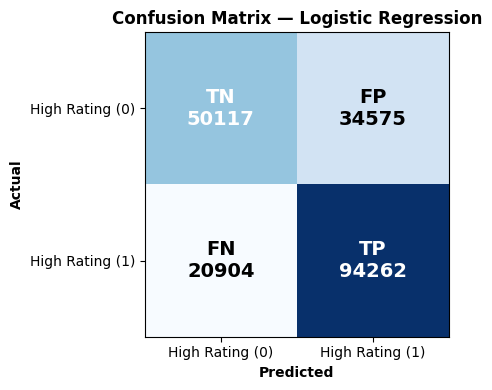

  TP=94262  FP=34575  TN=50117  FN=20904
  Precision = TP/(TP+FP) = 94262/128837 = 0.732
  Recall    = TP/(TP+FN) = 94262/115166 = 0.818


[Stage 626:======>                                                  (1 + 8) / 9]

+-----------+----------+-----+
|high_rating|prediction|count|
+-----------+----------+-----+
|          1|       0.0|20904|
|          0|       0.0|50117|
|          1|       1.0|94262|
|          0|       1.0|34575|
+-----------+----------+-----+



In [50]:
import numpy as np
import matplotlib.pyplot as plt
def plot_confusion_matrix(predictions, title, label_col="high_rating"):
    """Compute and plot a confusion matrix from Spark predictions."""
    
    cm_df = predictions.groupBy(label_col, "prediction").count().toPandas()

    # Build 2x2 matrix
    cm = np.zeros((2, 2), dtype=int)
    for _, row in cm_df.iterrows():
        actual = int(row[label_col])
        pred   = int(row["prediction"])
        cm[actual][pred] = int(row["count"])

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")

    # Labels
    labels = ["High Rating (0)", "High Rating (1)"]
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted", fontweight="bold")
    ax.set_ylabel("Actual", fontweight="bold")
    ax.set_title(title, fontweight="bold")

    # Annotate cells
    cell_labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i][j] > cm.max() / 2 else "black"
            ax.text(j, i, f"{cell_labels[i][j]}\n{cm[i][j]}",
                    ha="center", va="center", fontsize=14,
                    fontweight="bold", color=color)

    plt.tight_layout()
    plt.show()

    # Print derived metrics
    tp, fp, tn, fn = cm[1][1], cm[0][1], cm[0][0], cm[1][0]
    print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
    if tp + fp > 0:
        print(f"  Precision = TP/(TP+FP) = {tp}/{tp+fp} = {tp/(tp+fp):.3f}")
    if tp + fn > 0:
        print(f"  Recall    = TP/(TP+FN) = {tp}/{tp+fn} = {tp/(tp+fn):.3f}")

print("Logistic Regression:")
plot_confusion_matrix(predictions, "Confusion Matrix — Logistic Regression")
predictions.groupBy("high_rating", "prediction").count().show()

## Part 3: Model Interpretation

### 3a. Coefficient Analysis


Logistic Regression Coefficients:
──────────────────────────────────────────────────
movie_avg_rating          +0.9522  --> increases high_rating
user_avg_rating           +0.7478  --> increases high_rating
user_rating_count         +0.0981  --> increases high_rating
Age                       -0.0953  --> decreases high_rating
num_genres                -0.0129  --> decreases high_rating
gender_encoded            -0.0093  --> decreases high_rating
Occupation                +0.0080  --> increases high_rating
movie_age                 -0.0078  --> decreases high_rating
release_year              +0.0078  --> increases high_rating
movie_popularity          +0.0011  --> increases high_rating

Intercept: -12.9665


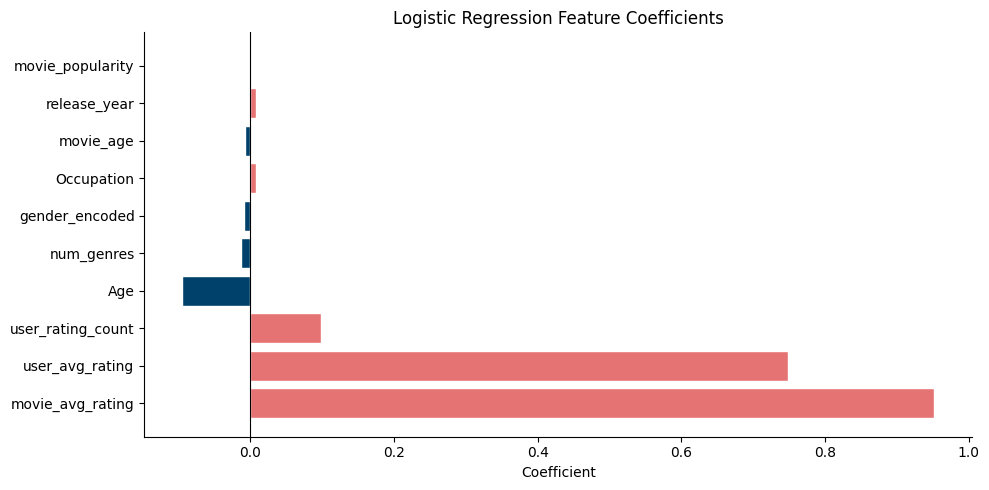

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Get fitted Logistic Regression model
lr_model = model.stages[-1]

# Create and sort coefficient table
coeff_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr_model.coefficients.toArray()
})

coeff_df["abs_coeff"] = coeff_df["coefficient"].abs()
coeff_df = coeff_df.sort_values("abs_coeff", ascending=False)

# Print interpretation
print("\nLogistic Regression Coefficients:")
print("─" * 50)
for _, row in coeff_df.iterrows():
    direction = "increases high_rating" if row["coefficient"] > 0 else "decreases high_rating"
    print(f"{row['feature']:<25} {row['coefficient']:+.4f}  --> {direction}")

print(f"\nIntercept: {lr_model.intercept:.4f}")


### 3b. Feature Importance Visualization

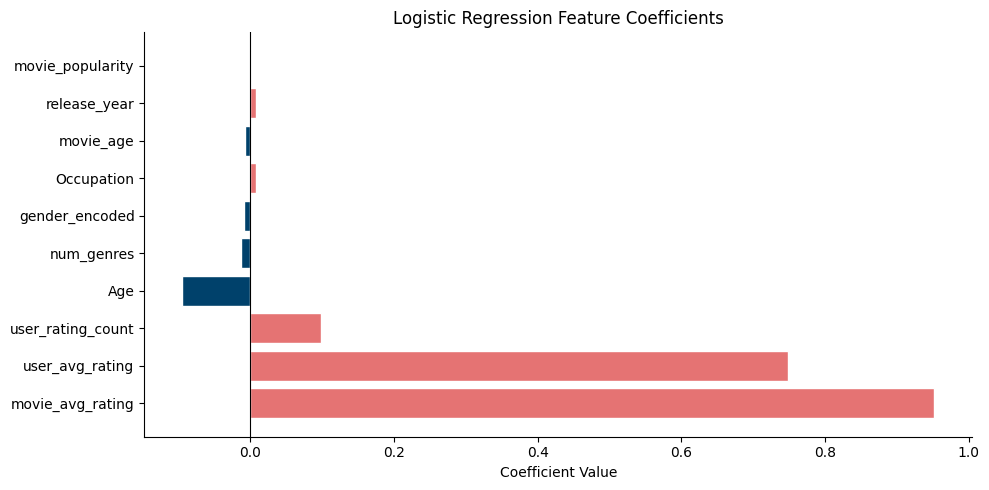

In [58]:
import matplotlib.pyplot as plt


# Bar chart
names = coeff_df["feature"].tolist()
coefs = coeff_df["coefficient"].tolist()
colors = ["#E57373" if c > 0 else "#00416B" for c in coefs]

fig, ax = plt.subplots(figsize=(10, max(4, len(names) * 0.5)))
ax.barh(names, coefs, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient Value")
ax.set_title("Logistic Regression Feature Coefficients")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### 3c. Connection to D2

## Part 4: Reflection

1. **Model performance**: How much did your model improve over the naive baseline? Look at AUC-PR specifically. Then look at your confusion matrix — are false positives or false negatives the bigger problem for a recommendation system? (A false positive recommends a movie the user won't like; a false negative hides a movie they would have liked.)

2. **Linearity limitation:** Logistic Regression treats each feature independently — it cannot capture interactions between features. For example, does genre affect ratings differently for different age groups or genders? Pick one plausible interaction from your features and explain why Logistic Regression would miss it. How might you address this in D4?


3. **What would improve the model?** List at least 2 concrete changes you plan to try in D4 (e.g., add interaction features, try a different algorithm, tune hyperparameters). Be specific — "make it better" is not a plan.


4. **Feature design choice:** MovieLens provides age as bucketed ranges (18, 25, 35, ...). You could use the midpoint as a single numeric feature (assumes a linear relationship with ratings) or encode each bucket as a separate category (no linearity assumption, but uses more parameters). Which did you choose, and why? What would change if you switched to the other approach?